In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("../data/processed/AAPL_processed.csv")

df.head()


,Date,Close,High,Low,Open,Volume,Daily_Return,Rolling_Mean_7,Rolling_Std_7,MA_7,...,RSI_14,BB_Middle,BB_Std,BB_Upper,BB_Lower,Rolling_Return_Mean_30,Rolling_Return_Std_30,Sharpe_30,Future_Volatility_7,Risk_Label
0,2015-03-30,28.099451,28.106122,27.572461,27.583579,188398800,0.025314,27.859620,0.016876,27.859620,...,54.061164,27.993163,0.438978,28.871118,27.115208,-0.000091,0.014099,-0.006424,0.011207,1
1,2015-03-31,27.668066,28.126124,27.652501,28.037180,168362400,-0.015352,27.812924,0.017221,27.812924,...,54.851553,27.938351,0.404726,28.747804,27.128898,-0.000799,0.014320,-0.055798,0.008856,0
2,2015-04-01,27.628052,27.821504,27.372339,27.754796,162485600,-0.001446,27.718899,0.016413,27.718899,...,49.513164,27.890655,0.380361,28.651377,27.129934,-0.001079,0.014245,-0.075769,0.008902,0
3,2015-04-02,27.865974,27.919340,27.614710,27.801490,128880400,0.008612,27.675380,0.016996,27.675380,...,54.168661,27.878537,0.376905,28.632347,27.124726,-0.000722,0.014352,-0.050330,0.008886,0
4,2015-04-06,28.317362,28.352940,27.645840,27.676970,148776000,0.016199,27.801489,0.014011,27.801489,...,55.602294,27.886875,0.384999,28.656873,27.116878,-0.000455,0.014596,-0.031163,0.006222,0


In [3]:
df.columns


Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Daily_Return',
       'Rolling_Mean_7', 'Rolling_Std_7', 'MA_7', 'MA_30', 'Volatility_7',
       'Volatility_30', 'Cumulative_Return', 'Rolling_Max', 'Drawdown',
       'RSI_14', 'BB_Middle', 'BB_Std', 'BB_Upper', 'BB_Lower',
       'Rolling_Return_Mean_30', 'Rolling_Return_Std_30', 'Sharpe_30',
       'Future_Volatility_7', 'Risk_Label'],
      dtype='object')

In [5]:
feature_columns = [
    "Close",
    "Volume",
    "Daily_Return",
    "MA_7",
    "MA_30",
    "Volatility_7",
    "Volatility_30",
    "Drawdown",
    "RSI_14",
    "BB_Upper",
    "BB_Lower",
    "Sharpe_30"
]

X = df[feature_columns]
y = df["Risk_Label"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)


Feature shape: (2198, 12)
Target shape: (2198,)


In [6]:
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)


Train size: (1758, 12)
Test size: (440, 12)


In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [8]:
import joblib

joblib.dump(scaler, "../models/scaler.pkl")


['../models/scaler.pkl']

In [13]:
X_train.shape


(1758, 12)

In [14]:
X_test.shape


(440, 12)

In [15]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

log_preds = log_model.predict(X_test_scaled)


In [16]:
from sklearn.metrics import classification_report, accuracy_score

print("Logistic Regression Accuracy:", accuracy_score(y_test, log_preds))
print("\nClassification Report:\n")
print(classification_report(y_test, log_preds))


Logistic Regression Accuracy: 0.48409090909090907

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.01      0.02       120
           1       0.36      0.53      0.43       146
           2       0.60      0.77      0.68       174

    accuracy                           0.48       440
   macro avg       0.65      0.44      0.37       440
weighted avg       0.63      0.48      0.41       440



In [17]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)


In [18]:
print("Random Forest Accuracy:", accuracy_score(y_test, rf_preds))
print("\nClassification Report:\n")
print(classification_report(y_test, rf_preds))


Random Forest Accuracy: 0.32272727272727275

Classification Report:

              precision    recall  f1-score   support

           0       0.10      0.05      0.07       120
           1       0.41      0.28      0.33       146
           2       0.34      0.55      0.42       174

    accuracy                           0.32       440
   macro avg       0.28      0.29      0.27       440
weighted avg       0.30      0.32      0.30       440



In [19]:
df["Risk_Label"].value_counts()


Risk_Label
2    747
0    726
1    725
Name: count, dtype: int64

In [20]:
from sklearn.linear_model import LogisticRegression

log_model_balanced = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

log_model_balanced.fit(X_train_scaled, y_train)

log_preds_balanced = log_model_balanced.predict(X_test_scaled)

print("Balanced Logistic Accuracy:", accuracy_score(y_test, log_preds_balanced))
print("\nClassification Report:\n")
print(classification_report(y_test, log_preds_balanced))


Balanced Logistic Accuracy: 0.4818181818181818

Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       120
           1       0.36      0.53      0.43       146
           2       0.60      0.77      0.68       174

    accuracy                           0.48       440
   macro avg       0.32      0.43      0.37       440
weighted avg       0.36      0.48      0.41       440



C:\Users\HP\anaconda3\envs\stockrisk\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\HP\anaconda3\envs\stockrisk\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\HP\anaconda3\envs\stockrisk\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.sh

In [21]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    eval_metric="mlogloss"
)

xgb_model.fit(X_train, y_train)

xgb_preds = xgb_model.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, xgb_preds))
print("\nClassification Report:\n")
print(classification_report(y_test, xgb_preds))


XGBoost Accuracy: 0.32954545454545453

Classification Report:

              precision    recall  f1-score   support

           0       0.22      0.10      0.14       120
           1       0.32      0.55      0.40       146
           2       0.39      0.30      0.34       174

    accuracy                           0.33       440
   macro avg       0.31      0.32      0.29       440
weighted avg       0.32      0.33      0.31       440



In [22]:
import numpy as np

print("Unique predictions:", np.unique(log_preds_balanced))


Unique predictions: [1 2]


In [23]:
print("Unique XGB predictions:", np.unique(xgb_preds))


Unique XGB predictions: [0 1 2]


In [24]:
high_threshold = df["Future_Volatility_7"].quantile(0.66)

df["High_Risk"] = (df["Future_Volatility_7"] > high_threshold).astype(int)

df["High_Risk"].value_counts()


High_Risk
0    1451
1     747
Name: count, dtype: int64

In [25]:
y_binary = df["High_Risk"]

X = df[feature_columns]


In [26]:
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y_binary.iloc[:split_index]
y_test = y_binary.iloc[split_index:]


In [27]:
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

xgb_preds = xgb_model.predict(X_test)

print("Binary XGBoost Accuracy:", accuracy_score(y_test, xgb_preds))
print("\nClassification Report:\n")
print(classification_report(y_test, xgb_preds))


Binary XGBoost Accuracy: 0.6772727272727272

Classification Report:

              precision    recall  f1-score   support

           0       0.66      0.95      0.78       266
           1       0.79      0.25      0.38       174

    accuracy                           0.68       440
   macro avg       0.72      0.60      0.58       440
weighted avg       0.71      0.68      0.62       440



In [28]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

scale_pos_weight


np.float64(2.068062827225131)

In [29]:
xgb_model_weighted = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight
)

xgb_model_weighted.fit(X_train, y_train)

xgb_preds_weighted = xgb_model_weighted.predict(X_test)

print("Weighted XGBoost Accuracy:", accuracy_score(y_test, xgb_preds_weighted))
print("\nClassification Report:\n")
print(classification_report(y_test, xgb_preds_weighted))


Weighted XGBoost Accuracy: 0.6568181818181819

Classification Report:

              precision    recall  f1-score   support

           0       0.67      0.83      0.75       266
           1       0.60      0.39      0.47       174

    accuracy                           0.66       440
   macro avg       0.64      0.61      0.61       440
weighted avg       0.65      0.66      0.64       440



In [30]:
import matplotlib.pyplot as plt

feature_importance = xgb_model_weighted.feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": feature_importance
}).sort_values(by="Importance", ascending=False)

importance_df


,Feature,Importance
9,BB_Upper,0.113941
10,BB_Lower,0.109437
6,Volatility_30,0.106603
5,Volatility_7,0.092394
4,MA_30,0.090086
8,RSI_14,0.085658
3,MA_7,0.084232
7,Drawdown,0.075279
11,Sharpe_30,0.074774
1,Volume,0.073215


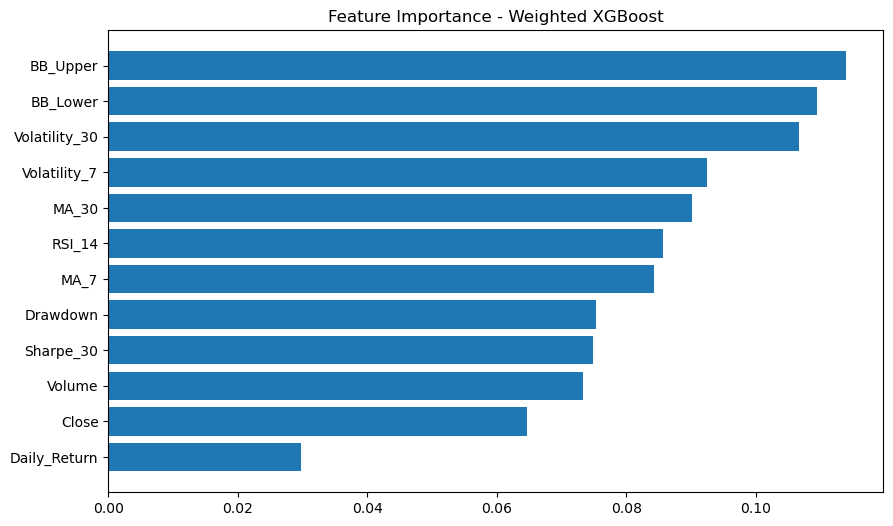

In [31]:
plt.figure(figsize=(10,6))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance - Weighted XGBoost")
plt.show()


In [33]:
pip install shap


  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
   ---------------------------------------- 0.0/552.3 kB ? eta -:--:--
   ------------------ --------------------- 262.1/552.3 kB ? eta -:--:--
   ---------------------------------------- 552.3/552.3 kB 3.7 MB/s  0:00:00
   ---------------------------------------- 0.0/39.1 MB ? eta -:--:--
   --- ------------------------------------ 3.4/39.1 MB 15.7 MB/s eta 0:00:03
   ------- -------------------------------- 7.3/39.1 MB 17.4 MB/s eta 0:00:02
   ------------ --------------------------- 12.6/39.1 MB 19.5 MB/s eta 0:00:02
   ------------------ --------------------- 18.1/39.1 MB 21.2 MB/s eta 0:00:01
   ------------------------ --------------- 23.6/39.1 MB 22.6 MB/s eta 0:00:01
   ------------------------------ --------- 29.4/39.1 MB 23.5 MB/s eta 0:00:01
   ------------------------------------- -- 3

C:\Users\HP\anaconda3\envs\stockrisk\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


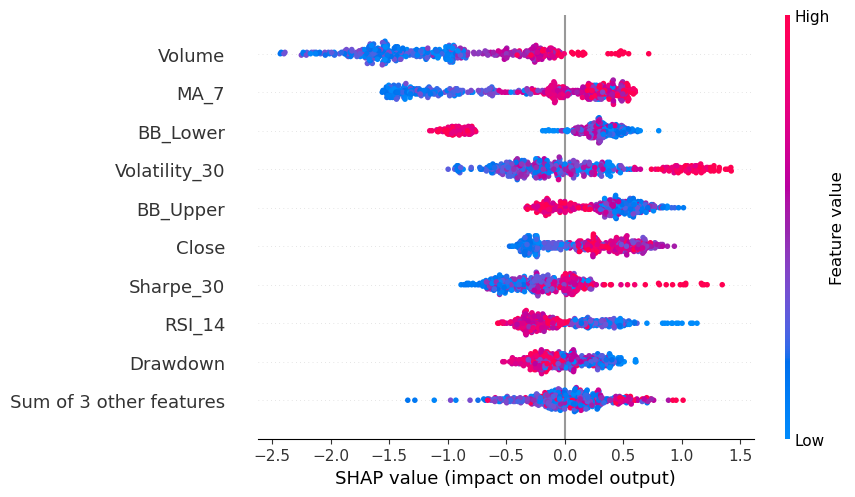

In [34]:
import shap

explainer = shap.Explainer(xgb_model_weighted)
shap_values = explainer(X_test)

shap.plots.beeswarm(shap_values)
